# Mixed-Field Ising Model (MFIM) evolution using Matrix Product Operator (MPO)

with bond dimension χ controlled by operator entanglement.



In [278]:
# using Pkg; Pkg.add("ITensors"); Pkg.add("ITensorMPS")
using ITensors, ITensorMPS
# using Pkg; Pkg.add("LaTeXStrings")
using LaTeXStrings
using Plots

#include("../src/matrix_product_operator_functions.jl")
include("matrix_product_operator_functions.jl")
import .mpo_functions as mpo

## MFIM's Hamiltonian

$$H = \sum_j ( X_j X_{j+1} + gX_j + hZ_j ) \quad \text{with} \quad g=1/2, h=1/2$$

In [279]:
g = 0.5
h = 0.5

0.5

---
# 1. Introduction

Before we gonna focus on a simple and controlled setting in order to validate the method and build intuition before moving to more complex circuits and operator.

We consider a system of $N=6$ qubits (particles $1/2$) arranged on a 1D chain. The quantum dynamics is generated by a circuit composed of **two-qubit gates** applied in a **bricklayer pattern**.

In [280]:
# nombre de spins
N = 6

# creation des sites
sites = ITensors.siteinds("S=1/2", N)

6-element Vector{Index{Int64}}:
 (dim=2|id=476|"S=1/2,Site,n=1")
 (dim=2|id=768|"S=1/2,Site,n=2")
 (dim=2|id=186|"S=1/2,Site,n=3")
 (dim=2|id=215|"S=1/2,Site,n=4")
 (dim=2|id=918|"S=1/2,Site,n=5")
 (dim=2|id=33|"S=1/2,Site,n=6")

---

# 2. Temporal evolution

In the Heisenberg picture, the evolution applies to the operator.

We will therefore seek here to evolve our operator $\hat{O}$,
which is defined by:

$$\hat{O}(t) = U^{\dagger}\hat{O}U$$

Let us then calculate the evolution operator $U = e^{-iHt}$.

Calculating $U$ for $N$ that is too large is too computationally expensive, we will seek to simplify it by using:

### Trotter decomposition

$$H = \sum_j h_{j,j+1} \quad \text{where} \quad h_{j,j+1} = X_jX_{j+1} +\frac{g}{2}( X_j+X_{j+1})+\frac{h}{2}( Z_j+Z_{j+1})$$

$H$ can be decompose between $j_{odd}$ and $j_{even}$ so $H = H_{odd} + H_{even}$.

We take a small time step $\tau << 1$,
we can use the Baker-Campbell-Hausdorff formula to approximate :

$$U(\tau) = e^{-i \tau H} = e^{-i \tau (H_{odd} + H_{even})} = e^{-i \tau H_o} e^{-i \tau H_e} e^{-i \tau^2 [H_o,H_e]} = e^{-i \tau H_o} e^{-i \tau H_e} + O(\tau^2)$$
because of
$$e^{-i \tau^2 [H_o,H_e]} = \mathbb{I} - i \tau^2 [H_o, H_e] + O(\tau^4) $$

We have an error per time step $\tau$ of order $\tau^2$.

the $h_{j,j+1}$ for $j$ odd or even commute with each other, so

$$e^{-i \tau H_o} = e^{-i \tau \sum_{j_{odd}}h_{j,j+1}} = \prod_{j_{odd}} e^{-i \tau h_{j,j+1}} $$

same for $H_{even}$.

in conclusion we take

$$U^{TEBD2}(\tau) = e^{-iH\tau} \approx \prod_{j_{odd}}e^{-i\tau h_{j,j+1}/2} \prod_{j_{even}}e^{-i\tau h_{j,j+1}} \prod_{j_{odd}}e^{-i\tau h_{j,j+1}/2}$$

Wich have an error order of $\tau^3$.

Each term: $e^{-i\tau h_{j,j+1}}$ acts only on 2 spins.
Therefore, it can be represented as a 4-index tensor.
This is called a **TEBD gate**.

In [281]:
# Hamiltonien local h_{j,j+1}
function build_two_site_hamiltonian(j::Int64, N::Int64, g::Float64=0.5, h::Float64=0.5)
  s1 = sites[j]
  s2 = sites[j + 1]

  # Terme d'interaction ZZ
  hj = op("X", s1) * op("X", s2)

  # Gestion du champ pour le site de gauche (s1)
  # Si on est au bord gauche (j=1), on met le champ complet, sinon la moitié
  g1 = (j == 1) ? g : g/2
  h1 = (j == 1) ? h : h/2
  hj += g1 * (op("X", s1) * op("Id", s2)) + h1 * (op("Z", s1) * op("Id", s2))

  # Gestion du champ pour le site de droite (s2)
  # Si on est au bord droit (j=N-1), on met le champ complet, sinon la moitié
  g2 = (j == N - 1) ? g : g/2
  h2 = (j == N - 1) ? h : h/2
  hj += g2 * (op("Id", s1) * op("X", s2)) + h2 * (op("Id", s1) * op("Z", s2))

  return hj
end

# Construction des gates TEBD
function build_gates_hj(τ::Float64, N::Int64, g::Float64=0.5, h::Float64=0.5)
  gates_odd = ITensor[]
  gates_even = ITensor[]
  for j in 1:(N-1)
      hj = build_two_site_hamiltonian(j, N, g, h)
      if isodd(j)
        Gj = exp(-im * τ / 2 * hj)
        push!(gates_odd, Gj)
      else
        Gj = exp(-im * τ * hj)
        push!(gates_even, Gj)
      end
  end
  return gates_odd, gates_even
end

function compute_circuit(Nqubits::Int64, nlayers::Int64, τ::Float64, g::Float64=0.5, h::Float64=0.5)
  gates_odd, gates_even = build_gates_hj(τ, Nqubits, g, h)

  # On crée une seule liste ordonnée pour un pas de Trotter complet
  # Ordre : Odd (τ/2) -> Even (τ) -> Odd (τ/2)
  one_step_layer = vcat(gates_odd, gates_even, gates_odd)

  return [one_step_layer for _ in 1:nlayers]
end

compute_circuit (generic function with 3 methods)

---

# 3. Evolution of the Identity

If $\hat{O} = \mathbb{I}$ we have :

$$U^\dagger \mathbb{I} U = \mathbb{I} \qquad \forall U \text{ unitary}$$

Let's test the robustness of our method by verifying this result.

In [282]:
# construction MPO identite
IdMPO = MPO(sites, "Id")

6-element MPO:
 ((dim=2|id=476|"S=1/2,Site,n=1")', (dim=2|id=476|"S=1/2,Site,n=1"), (dim=1|id=406|"Link,l=1"))
 ((dim=2|id=768|"S=1/2,Site,n=2")', (dim=2|id=768|"S=1/2,Site,n=2"), (dim=1|id=117|"Link,l=2"), (dim=1|id=406|"Link,l=1"))
 ((dim=2|id=186|"S=1/2,Site,n=3")', (dim=2|id=186|"S=1/2,Site,n=3"), (dim=1|id=90|"Link,l=3"), (dim=1|id=117|"Link,l=2"))
 ((dim=2|id=215|"S=1/2,Site,n=4")', (dim=2|id=215|"S=1/2,Site,n=4"), (dim=1|id=383|"Link,l=4"), (dim=1|id=90|"Link,l=3"))
 ((dim=2|id=918|"S=1/2,Site,n=5")', (dim=2|id=918|"S=1/2,Site,n=5"), (dim=1|id=950|"Link,l=5"), (dim=1|id=383|"Link,l=4"))
 ((dim=2|id=33|"S=1/2,Site,n=6")', (dim=2|id=33|"S=1/2,Site,n=6"), (dim=1|id=950|"Link,l=5"))

In [283]:
println("Max bond dimension = ", maxlinkdim(IdMPO))

Max bond dimension = 1


max bond dimension $= 1 \implies \chi = 1$, it's the simpliest MPO possible.

In [284]:
# Simulation
cutoff = 1e-8
τ = 0.1
steps = 20

circuit = compute_circuit(N, steps, τ, g, h)
Ot, result = mpo.propagate_layerbylayer(circuit, IdMPO; cutoff)

println("Max bond dimension = ", maxlinkdim(Ot))
println("\nIdentity distance = ", norm(Ot - IdMPO))

layer : 2 /20 complete
layer : 4 /20 complete
layer : 6 /20 complete
layer : 8 /20 complete
layer : 10 /20 complete
layer : 12 /20 complete
layer : 14 /20 complete
layer : 16 /20 complete
layer : 18 /20 complete
layer : 20 /20 complete
Time taken by mpo_functions.propagate_layerbylayer: 1.2436671257019043 seconds
Max bond dimension = 1

Identity distance = 7.23987410334829e-15


This indeed gives the expected result:
$$U^{\dagger}\mathbb{I}U = \mathbb{I}$$
After applying the evolution, we arrive back at the identity, with a **numerical error** of the order of $10^{-15}$.

---

# 4. Propagation of a local operator

Let's take $\hat{O} = Z_3$ as an example of a local operator.

$$Z_3 = \mathbb{I} \otimes \mathbb{I} \otimes Z \otimes \mathbb{I} \otimes \mathbb{I} \otimes \mathbb{I}$$


In [285]:
# Z_3
j = 3

# Méthode OpSum
"""os = OpSum()
os += "Z", j
Z_j = MPO(os, sites)"""

# Méthode manuelle
ops = ["Id" for n in 1:N]
ops[j] = "Z"
Z_j = MPO(sites, ops)

println("Max bond dimension = ", maxlinkdim(Z_j))

Max bond dimension = 1


For $Z_3$, we obtain $\chi = 2$ so this is indeed a local operator.

In [286]:
# Simulation
steps = 20
circuit = compute_circuit(N, steps, τ, g, h)

Z_jt, result = mpo.propagate_layerbylayer(circuit, Z_j; cutoff)

println("Max bond dimension = ", maxlinkdim(Z_jt))

layer : 2 /20 complete
layer : 4 /20 complete
layer : 6 /20 complete
layer : 8 /20 complete
layer : 10 /20 complete
layer : 12 /20 complete
layer : 14 /20 complete
layer : 16 /20 complete
layer : 18 /20 complete
layer : 20 /20 complete
Time taken by mpo_functions.propagate_layerbylayer: 1.5829582214355469 seconds
Max bond dimension = 21


We observe an increase in the maximum bond dimension and a growth in $\chi$ due to operator entanglement caused by $X_jX_{j+1}$ in the Hamiltonian.

The bond dimension $\chi$ measures operator entanglement.

---

# 5. Operator Entanglement

If we divide the system into two parts: $A | B$

We would like to know 'how far' an operator $\hat{O}(t)$ is from a product operator,
$$\hat O \approx O^A \otimes O^B$$

The operator can be rewritten as a matrix:

$$\hat{O} = \sum_\alpha s_\alpha A_\alpha \otimes B_\alpha$$

where:
- $s_\alpha =$  singular values
- $A_\alpha$ acts on A
- $B_\alpha$ acts on B

This is a Schmidt decomposition of the operator.

### Operator Entanglement Entropy

is useful to determine whether an operator can be approximated by a Matrix Product Operator with small bond dimension

$$S_{op} = - \sum_{\alpha } p_\alpha log(p_\alpha)$$

with
$$p_\alpha = \frac{s_\alpha^2}{\sum_\beta s_\beta^2}$$


In [287]:
bond = N÷2
O = copy(Z_j)

steps = 500
circuit = compute_circuit(N, steps, τ, g, h)

Ot, result = mpo.propagate_layerbylayer(circuit, O; cutoff, bond)

S_values = result["S"]; chi_values = result["maxbond"]

layer : 50 /500 complete
layer : 100 /500 complete
layer : 150 /500 complete
layer : 200 /500 complete
layer : 250 /500 complete
layer : 300 /500 complete
layer : 350 /500 complete
layer : 400 /500 complete
layer : 450 /500 complete
layer : 500 /500 complete
Time taken by mpo_functions.propagate_layerbylayer: 35.874303102493286 seconds


500-element Vector{Int64}:
  3
  4
  4
  4
  5
  6
  8
  8
  8
  8
  8
 10
 11
  ⋮
 64
 64
 64
 64
 63
 64
 63
 64
 64
 64
 64
 64

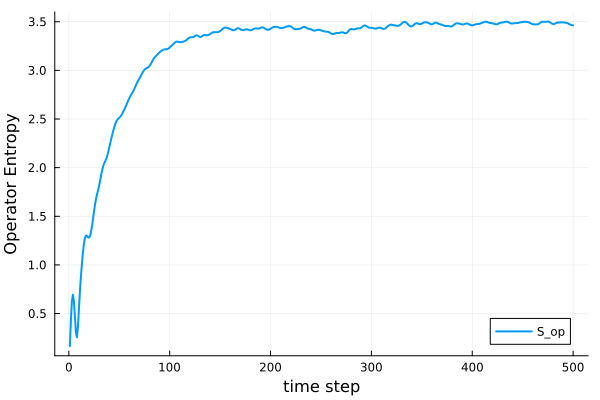

In [288]:
plot(1:steps, S_values,
     xlabel="time step",
     ylabel="Operator Entropy",
     label="S_op",
     lw=2)

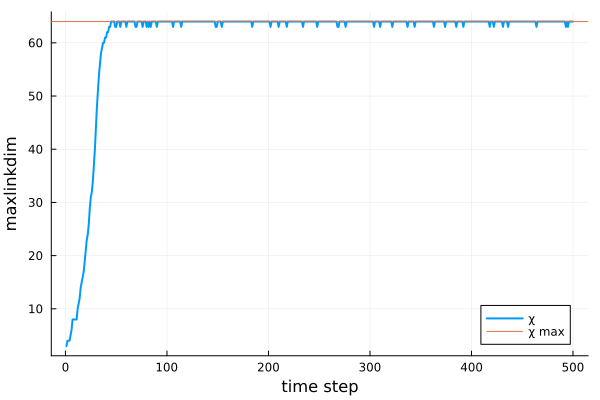

In [289]:
plot(1:steps, chi_values,
     xlabel="time step",
     ylabel="maxlinkdim",
     label="χ",
     lw=2)
hline!([2^N], label="χ max") # 2^N = dim max of the matrix

$$\chi \approx e^{S_{op}}$$

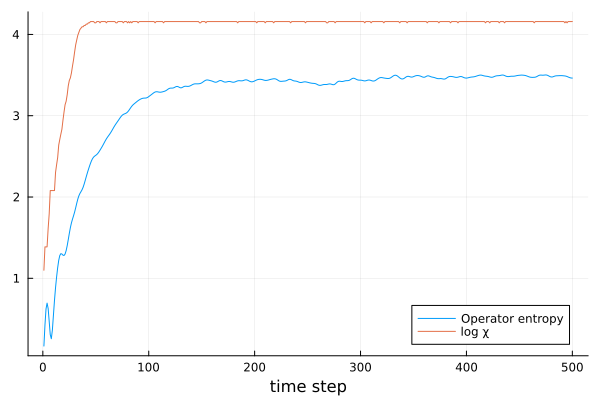

In [290]:
plot(1:steps, S_values,
     label="Operator entropy",
     xlabel="time step")

plot!(1:steps, log.(chi_values),
      label="log χ")

---

# 6. Hydrodynamic tails

$$Trace(X_i(t)X_0)$$

With $i=0$ wich represent the qubit in the center of the chain

---

## References

- [Julia documentation](https://docs.julialang.org/en/v1/)
- [ITensor documentation](https://docs.itensor.org/ITensors/stable/index.html)
- https://docs.juliaplots.org/dev/tutorial/
- https://www.phys.ens.psl.eu/~jacobsen/AMP21_Dubail.pdf
- https://tensornetwork.org/mps/algorithms/timeevo/tebd.html